# Experimento: Búsqueda en K-D Tree

Este notebook demuestra cómo funcionan las búsquedas de vecino más cercano usando k-d tree.

## 1. Importar Bibliotecas Necesarias

In [1]:
import sys
import os

# Cambiar al directorio correcto
os.chdir(r'c:\Users\joacr\OneDrive\Documentos\NetOptimizer')

import numpy as np
import matplotlib.pyplot as plt
import random
import time
import math

# Leer y ejecutar el archivo KD-tree.py directamente
with open('KD_tree.py', 'r', encoding='utf-8') as f:
    exec(f.read())

# Configurar visualizaciones
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
import importlib
import ExperimentoPrim

importlib.reload(ExperimentoPrim)

{1: {4: {'latencia': 2, 'ancho_banda': 100, 'costo': 180}, 5: {'latencia': 3, 'ancho_banda': 100, 'costo': 220}, 6: {'latencia': 2, 'ancho_banda': 100, 'costo': 160}, 7: {'latencia': 3, 'ancho_banda': 80, 'costo': 190}}, 4: {1: {'latencia': 2, 'ancho_banda': 100, 'costo': 180}, 3: {'latencia': 4, 'ancho_banda': 100, 'costo': 200}, 5: {'latencia': 1, 'ancho_banda': 100, 'costo': 80}}, 5: {1: {'latencia': 3, 'ancho_banda': 100, 'costo': 220}, 4: {'latencia': 1, 'ancho_banda': 100, 'costo': 80}, 8: {'latencia': 3, 'ancho_banda': 80, 'costo': 210}}, 6: {1: {'latencia': 2, 'ancho_banda': 100, 'costo': 160}, 7: {'latencia': 1, 'ancho_banda': 100, 'costo': 60}}, 7: {1: {'latencia': 3, 'ancho_banda': 80, 'costo': 190}, 6: {'latencia': 1, 'ancho_banda': 100, 'costo': 60}, 10: {'latencia': 5, 'ancho_banda': 40, 'costo': 100}}, 2: {9: {'latencia': 2, 'ancho_banda': 100, 'costo': 150}, 11: {'latencia': 4, 'ancho_banda': 80, 'costo': 120}, 10: {'latencia': 3, 'ancho_banda': 80, 'costo': 130}}, 9: {

<module 'ExperimentoPrim' from 'c:\\Users\\joacr\\OneDrive\\Documentos\\NetOptimizer\\ExperimentoPrim.py'>

## 2. Generar el grafo a partir del csv 

Nos apoyamos de los métodos de ExperimentoPrim.py para crear el grafo y luego graficarlo

{1: {4: {'latencia': 2, 'ancho_banda': 100, 'costo': 180}, 5: {'latencia': 3, 'ancho_banda': 100, 'costo': 220}, 6: {'latencia': 2, 'ancho_banda': 100, 'costo': 160}, 7: {'latencia': 3, 'ancho_banda': 80, 'costo': 190}}, 4: {1: {'latencia': 2, 'ancho_banda': 100, 'costo': 180}, 3: {'latencia': 4, 'ancho_banda': 100, 'costo': 200}, 5: {'latencia': 1, 'ancho_banda': 100, 'costo': 80}}, 5: {1: {'latencia': 3, 'ancho_banda': 100, 'costo': 220}, 4: {'latencia': 1, 'ancho_banda': 100, 'costo': 80}, 8: {'latencia': 3, 'ancho_banda': 80, 'costo': 210}}, 6: {1: {'latencia': 2, 'ancho_banda': 100, 'costo': 160}, 7: {'latencia': 1, 'ancho_banda': 100, 'costo': 60}}, 7: {1: {'latencia': 3, 'ancho_banda': 80, 'costo': 190}, 6: {'latencia': 1, 'ancho_banda': 100, 'costo': 60}, 10: {'latencia': 5, 'ancho_banda': 40, 'costo': 100}}, 2: {9: {'latencia': 2, 'ancho_banda': 100, 'costo': 150}, 11: {'latencia': 4, 'ancho_banda': 80, 'costo': 120}, 10: {'latencia': 3, 'ancho_banda': 80, 'costo': 130}}, 9: {

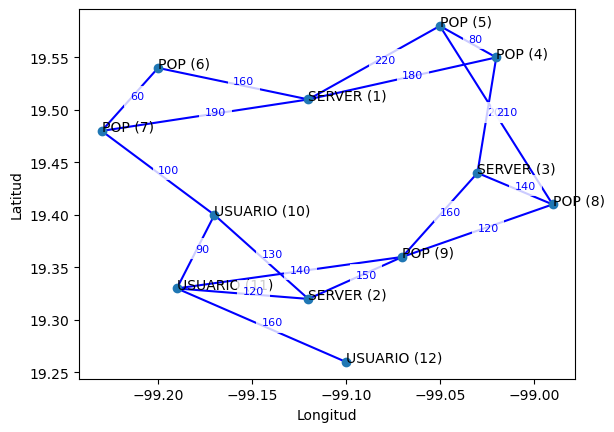

In [1]:
import matplotlib.pyplot as plt
import ExperimentoPrim
import Grafo

grafo = Grafo.Grafo()

x = []
y = []

nodos = ExperimentoPrim.insertaNodos()
grafoC = ExperimentoPrim.insertaElementos(grafo)
conexiones = ExperimentoPrim.conexiones(grafo)
direcciones = ExperimentoPrim.conexiones_con_pos(conexiones)

# NODOS
for tipo, latitud, longitud, id in nodos:

    x.append(longitud)
    y.append(latitud)

    plt.text(
        longitud,
        latitud,
        f"{tipo} ({id})" 
    )

# ARISTAS
for (origen_id, destino_id), (origen, destino) in zip(conexiones, direcciones):

    lat1, lon1 = origen
    lat2, lon2 = destino

    plt.plot(
        [lon1, lon2],
        [lat1, lat2],
        'b-',
        linewidth=1.5,
        zorder=1
    )

    # Calcular punto medio
    mid_lon = (lon1 + lon2) / 2
    mid_lat = (lat1 + lat2) / 2

    # Obtener costo_km desde el grafo usando ids de nodo
    costo = grafo.getOrigen()[origen_id][destino_id]["costo"]

    # Mostrar costo_km en medio de la línea
    plt.text(
        mid_lon,
        mid_lat,
        str(costo),
        fontsize=8,
        color='blue',
        bbox=dict(
            facecolor='white',
            alpha=0.8,
            edgecolor='none'
        ),
        zorder=7
    )

plt.scatter(x, y)

plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.show()

## 3. Uso de Prim

Graficamos el árbol de expansión más corto usando latencia como criterio de minimización 

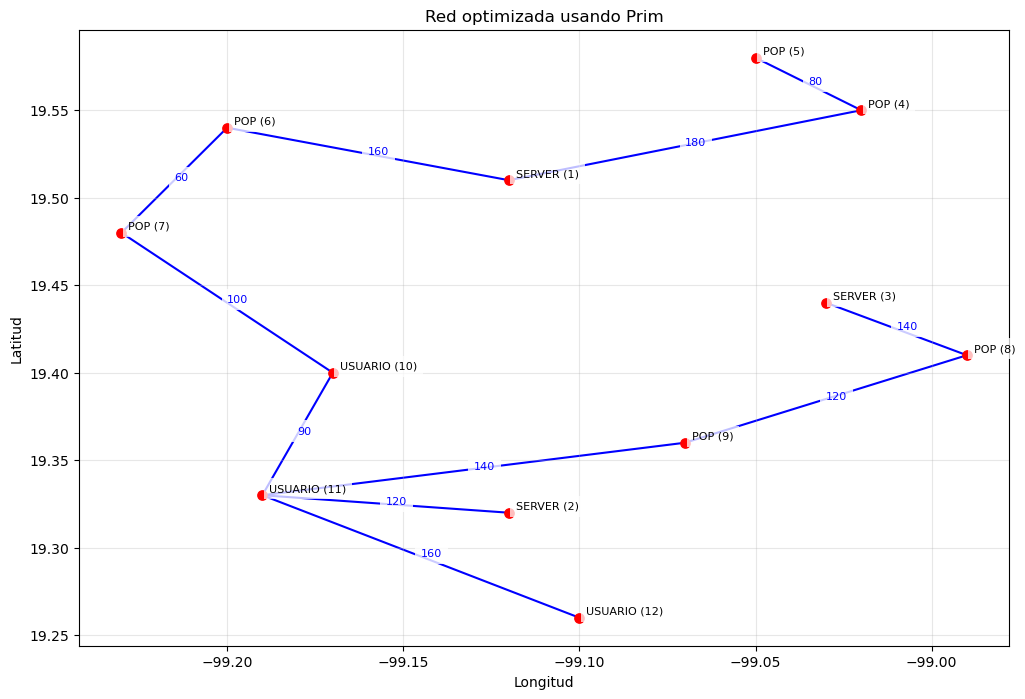

In [4]:
import matplotlib.pyplot as plt
import ExperimentoPrim


# Obtener conexiones del MST de Prim
referencias = ExperimentoPrim.referencias_despues_prim(grafo) # Con este método llamamos al prim con 1 y generamos las referencias
direcciones_nodos = ExperimentoPrim.conexiones_con_pos(referencias)


# Guardar posiciones de nodos
x = []
y = []

# GRAFICAR NODOS Y ETIQUETAS
for tipo, latitud, longitud, id_nodo in nodos:

    x.append(longitud)
    y.append(latitud)

    # Texto del nodo
    texto = f"{tipo} ({id_nodo})"

    # Nodo
    plt.scatter(
        longitud,
        latitud,
        c='red',
        s=45,
        zorder=5
    )

    # Etiqueta del nodo
    plt.text(
        longitud + 0.002,
        latitud + 0.002,
        texto,
        fontsize=8,
        bbox=dict(
            facecolor='white',
            alpha=0.75,
            edgecolor='none'
        ),
        zorder=6
    )

# GRAFICAR ARISTAS Y LATENCIAS
for (origen_id, destino_id), (origen, destino) in zip(referencias, direcciones_nodos):

    # Coordenadas origen/destino
    lat1, lon1 = origen
    lat2, lon2 = destino

    # Dibujar línea
    plt.plot(
        [lon1, lon2],
        [lat1, lat2],
        'b-',
        linewidth=1.5,
        zorder=1
    )

    # Calcular punto medio
    mid_lon = (lon1 + lon2) / 2
    mid_lat = (lat1 + lat2) / 2

    # Obtener latencia desde el grafo
    costo_km = grafo.getOrigen()[origen_id][destino_id]["costo"]

    # Mostrar latencia en medio de la línea
    plt.text(
        mid_lon,
        mid_lat,
        str(costo_km),
        fontsize=8,
        color='blue',
        bbox=dict(
            facecolor='white',
            alpha=0.8,
            edgecolor='none'
        ),
        zorder=7
    )

# Títulos
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Red optimizada usando Prim")

# Cuadrícula
plt.grid(alpha=0.3)

# Mostrar resultado
plt.show()

## 4. Construir el K-D Tree

El k-d tree organiza los puntos de manera jerárquica para permitir búsquedas eficientes.

In [5]:
# Construir el k-d tree sobre puntos de nodos
import KD_tree
arbol = KD_tree.kd_tree(2)

puntos_kd_server = [(latitud, longitud) for tipo, latitud, longitud, _ in nodos if tipo == "SERVER"]

#Los siguientes puntos solo son para graficarlos después
puntos_kd_no_server = [(latitud, longitud) for tipo, latitud, longitud, _ in nodos if tipo != "SERVER"]
puntos_kd_usuario = [(latitud, longitud) for tipo, latitud, longitud, _ in nodos if tipo == "USUARIO"]
puntos_kd_pop = [(latitud, longitud) for tipo, latitud, longitud, _ in nodos if tipo == "POP"]

inicio = time.time()
arbol.creaArbol(puntos_kd_server)
tiempo_construccion = time.time() - inicio

punto_busqueda = (19.53, -99.10)

print(f"✓ Árbol KD construido en {tiempo_construccion*1000:.4f} ms")
print(f"  Elementos: {arbol.elementos}")
print(f"  Dimensiones: {arbol.dimensiones}")


✓ Árbol KD construido en 0.0000 ms
  Elementos: 3
  Dimensiones: 2


## 4. Realizar Búsquedas de Vecino Más Cercano

Ahora vamos a buscar el punto más cercano a nuestro punto de consulta.

In [6]:
# Función auxiliar para calcular distancia euclidiana
def distancia_euclidiana(p1, p2):
    return math.sqrt(sum((p1[i] - p2[i])**2 for i in range(len(p1))))

# Buscar el vecino más cercano
inicio = time.time()
mejorp, mejord = arbol.busca(arbol.raiz, punto_busqueda, 0, None, 0)
tiempo_busqueda = time.time() - inicio
distancia = distancia_euclidiana(mejorp, punto_busqueda)

print(f"✓ Búsqueda completada en {tiempo_busqueda*1000:.4f} ms")
print(f"\nResultados:")
print(f"  Punto consultado: {punto_busqueda}")
print(f"  Vecino más cercano: {mejorp}")
print(f"  Distancia (al cuadrado): {mejord:.2f}")
print(f"  Distancia euclidiana: {distancia:.2f}")

✓ Búsqueda completada en 0.0000 ms

Resultados:
  Punto consultado: (19.53, -99.1)
  Vecino más cercano: (19.51, -99.12)
  Distancia (al cuadrado): 0.00
  Distancia euclidiana: 0.03


## 5. Visualizar Resultados

Graficamos los puntos, el punto de búsqueda y su vecino más cercano.

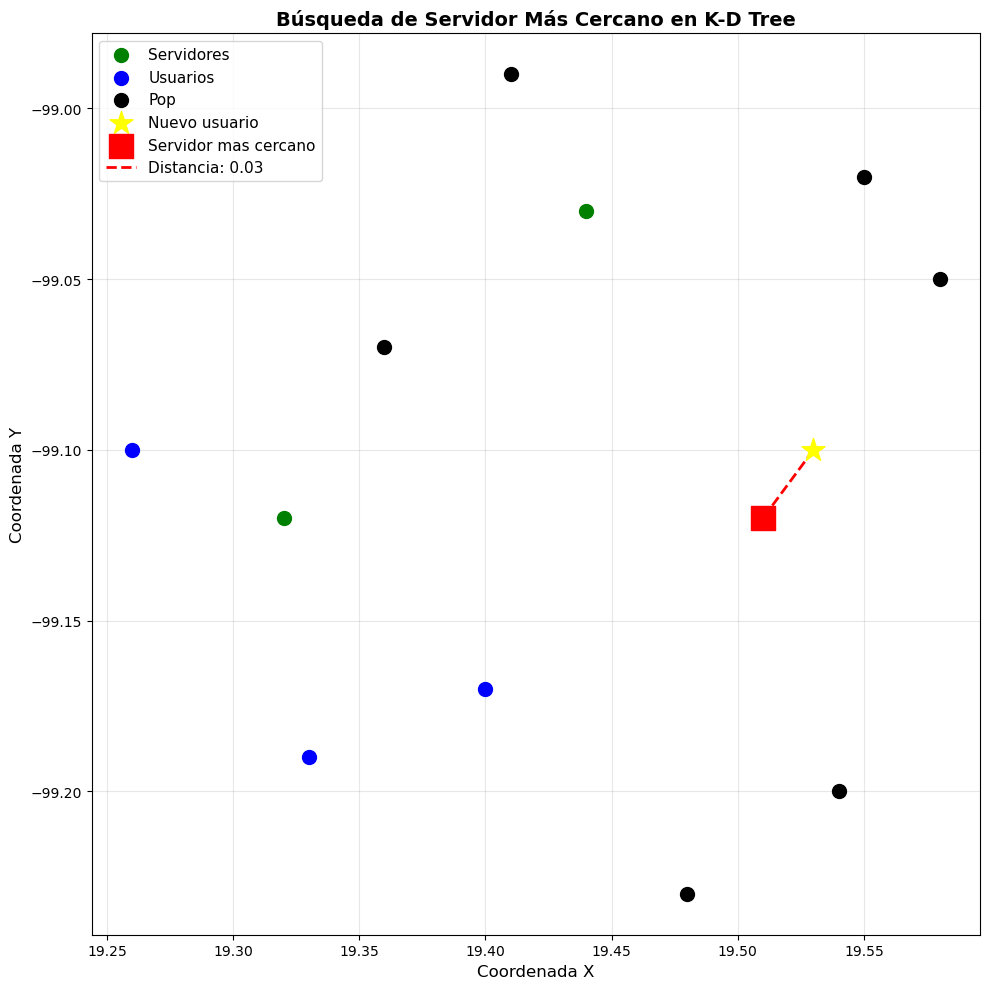

In [7]:
# Visualización
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Graficar todos los puntos
xs = [p[0] for p in puntos_kd_server] 
ys = [p[1] for p in puntos_kd_server]
#Estos puntos solo los generamos para poder poner los límites de los márgenes correctamente
xn = [p[0] for p in puntos_kd_no_server] 
yn = [p[1] for p in puntos_kd_no_server]

xu = [p[0] for p in puntos_kd_usuario] 
yu = [p[1] for p in puntos_kd_usuario]

xp = [p[0] for p in puntos_kd_pop] 
yp = [p[1] for p in puntos_kd_pop]

ax.scatter(xs, ys, c='green', s=100, label='Servidores', zorder=2)
ax.scatter(xu, yu, c='blue', label='Usuarios', s=100, zorder=2)
ax.scatter(xp, yp, c='black', label='Pop', s=100, zorder=2)


# Graficar punto de búsqueda
ax.scatter([punto_busqueda[0]], [punto_busqueda[1]], 
           c='yellow', s=300, marker='*', label='Nuevo usuario', zorder=3)

# Graficar vecino más cercano
ax.scatter([mejorp[0]], [mejorp[1]], 
           c='red', s=300, marker='s', label='Servidor mas cercano', zorder=3)

# Dibujar línea conectando punto de búsqueda con vecino más cercano

ax.plot([punto_busqueda[0], mejorp[0]], 
        [punto_busqueda[1], mejorp[1]], 
        'r--', linewidth=2, label=f'Distancia: {distancia:.2f}')

# Ajustar los ejes al rango real de los datos
margen_x = (max(xn) - min(xn)) * 0.05 
margen_y = (max(yn) - min(yn)) * 0.05
ax.set_xlim(min(xn) - margen_x, max(xn) + margen_x)
ax.set_ylim(min(yn) - margen_y, max(yn) + margen_y)
ax.set_xlabel('Coordenada X', fontsize=12)
ax.set_ylabel('Coordenada Y', fontsize=12)
ax.set_title('Búsqueda de Servidor Más Cercano en K-D Tree', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Búsquedas Múltiples

Realicemos varias búsquedas en diferentes puntos.

In [8]:
# Realizar múltiples búsquedas
puntos_consulta = [(19.53, -99.05), (19.30, -99.17), (19.50, -99.19), (19.35, -99.10), (19.45, -99.05)]

print("Múltiples búsquedas:")
print("-" * 60)
print(f"{'Punto Buscado':<20} {'Vecino Más Cercano':<20} {'Distancia':<10}")
print("-" * 60)

for pc in puntos_consulta:
    mejorp, mejord = arbol.busca(arbol.raiz, pc, 0, None, 0)
    dist = distancia_euclidiana(mejorp, pc)
    print(f"{str(pc):<20} {str(mejorp):<20} {dist:<10.2f}")

Múltiples búsquedas:
------------------------------------------------------------
Punto Buscado        Vecino Más Cercano   Distancia 
------------------------------------------------------------
(19.53, -99.05)      (19.51, -99.12)      0.07      
(19.3, -99.17)       (19.32, -99.12)      0.05      
(19.5, -99.19)       (19.51, -99.12)      0.07      
(19.35, -99.1)       (19.32, -99.12)      0.04      
(19.45, -99.05)      (19.44, -99.03)      0.02      


## 7. Análisis de Rendimiento: K-D Tree vs Búsqueda Lineal

In [9]:
# Función de búsqueda lineal para comparación
def busqueda_lineal(puntos, punto_busqueda, dimensiones):
    mejorp = None
    mejord = float('inf')
    
    for p in puntos:
        d = sum((p[i] - punto_busqueda[i])**2 for i in range(dimensiones))
        if d < mejord:
            mejord = d
            mejorp = p
    
    return mejorp, mejord

# Comparación de rendimiento con diferentes tamaños
tamaños = [50, 100, 500, 1000, 5000]
resultados = []
dimensiones = 2

print("\nComparación de Rendimiento (100 búsquedas por conjunto):")
print("-" * 80)
print(f"{'Tamaño':<15} {'KD-tree (ms)':<20} {'Búsqueda Lineal (ms)':<20} {'Mejora':<10}")
print("-" * 80)

for tamaño in tamaños:
    pts = [tuple(random.randint(0, 1000) for _ in range(dimensiones)) for _ in range(tamaño)]
    pt_busq = (500, 500)
    
    # KD-tree
    arb = kd_tree(dimensiones)
    arb.creaArbol(pts)
    inicio = time.time()
    for _ in range(100):
        arb.busca(arb.raiz, pt_busq, 0, None, 0)
    tiempo_kd = (time.time() - inicio) * 1000
    
    # Búsqueda lineal
    inicio = time.time()
    for _ in range(100):
        busqueda_lineal(pts, pt_busq, dimensiones)
    tiempo_lineal = (time.time() - inicio) * 1000
    
    mejora = tiempo_lineal / tiempo_kd
    resultados.append((tamaño, tiempo_kd, tiempo_lineal, mejora))
    
    print(f"{tamaño:<15} {tiempo_kd:<20.4f} {tiempo_lineal:<20.4f} {mejora:.2f}x")

print("-" * 80)


Comparación de Rendimiento (100 búsquedas por conjunto):
--------------------------------------------------------------------------------
Tamaño          KD-tree (ms)         Búsqueda Lineal (ms) Mejora    
--------------------------------------------------------------------------------
50              8.0173               11.9872              1.50x
100             9.2442               29.0098              3.14x
500             5.0004               107.0213             21.40x
1000            8.9817               225.2305             25.08x
5000            7.0062               1082.5162            154.51x
--------------------------------------------------------------------------------


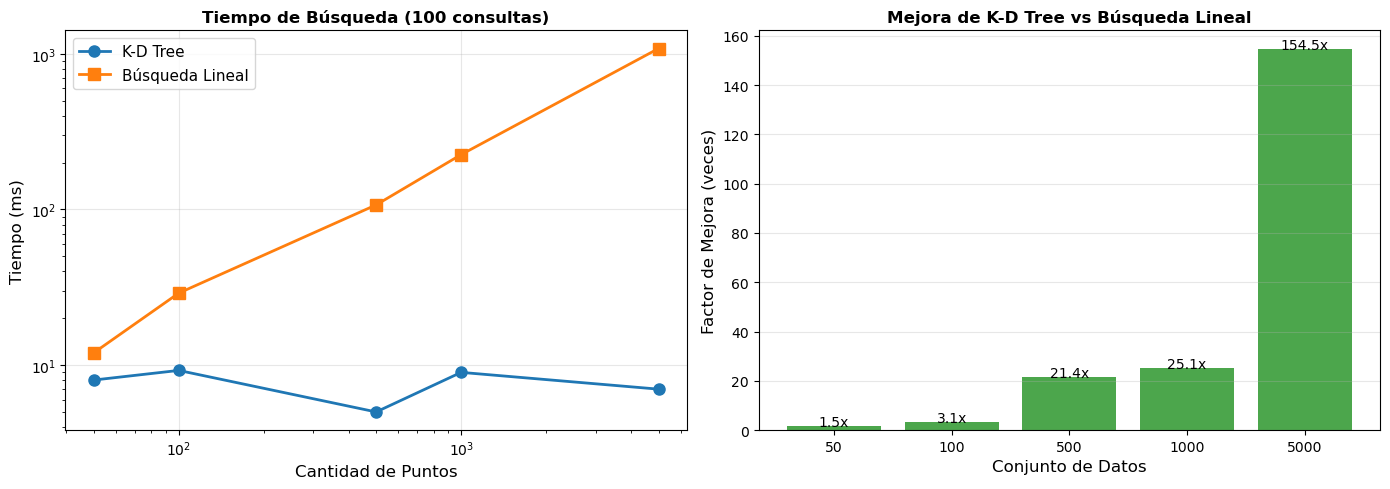

In [10]:
# Graficar comparación de rendimiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

tamaños_plot = [r[0] for r in resultados]
kd_times = [r[1] for r in resultados]
lineal_times = [r[2] for r in resultados]
mejoras = [r[3] for r in resultados]

# Gráfico de tiempos
ax1.plot(tamaños_plot, kd_times, 'o-', label='K-D Tree', linewidth=2, markersize=8)
ax1.plot(tamaños_plot, lineal_times, 's-', label='Búsqueda Lineal', linewidth=2, markersize=8)
ax1.set_xlabel('Cantidad de Puntos', fontsize=12)
ax1.set_ylabel('Tiempo (ms)', fontsize=12)
ax1.set_title('Tiempo de Búsqueda (100 consultas)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')
ax1.set_yscale('log')

# Gráfico de mejora
ax2.bar(range(len(tamaños_plot)), mejoras, color='green', alpha=0.7)
ax2.set_xlabel('Conjunto de Datos', fontsize=12)
ax2.set_ylabel('Factor de Mejora (veces)', fontsize=12)
ax2.set_title('Mejora de K-D Tree vs Búsqueda Lineal', fontsize=12, fontweight='bold')
ax2.set_xticks(range(len(tamaños_plot)))
ax2.set_xticklabels(tamaños_plot)
ax2.grid(True, alpha=0.3, axis='y')

# Agregar valores en las barras
for i, v in enumerate(mejoras):
    ax2.text(i, v + 0.1, f'{v:.1f}x', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## EXTRA: Ahora vamos a medir la ruta más óptima considerando todos los factores
Para esto vamos a buscar maximizar el ancho de banda, minimizar la latencia y minimizar el costo. 
La manera de hacerlo va a ser pensando la distancia de una manera distinta, en vez de direcciones vamos a considerar la distancia de un nodo a otro como dis = Δ (1/ ancho de banda) ^2 +  Δ latencia ^2 + Δ costo ^ 2

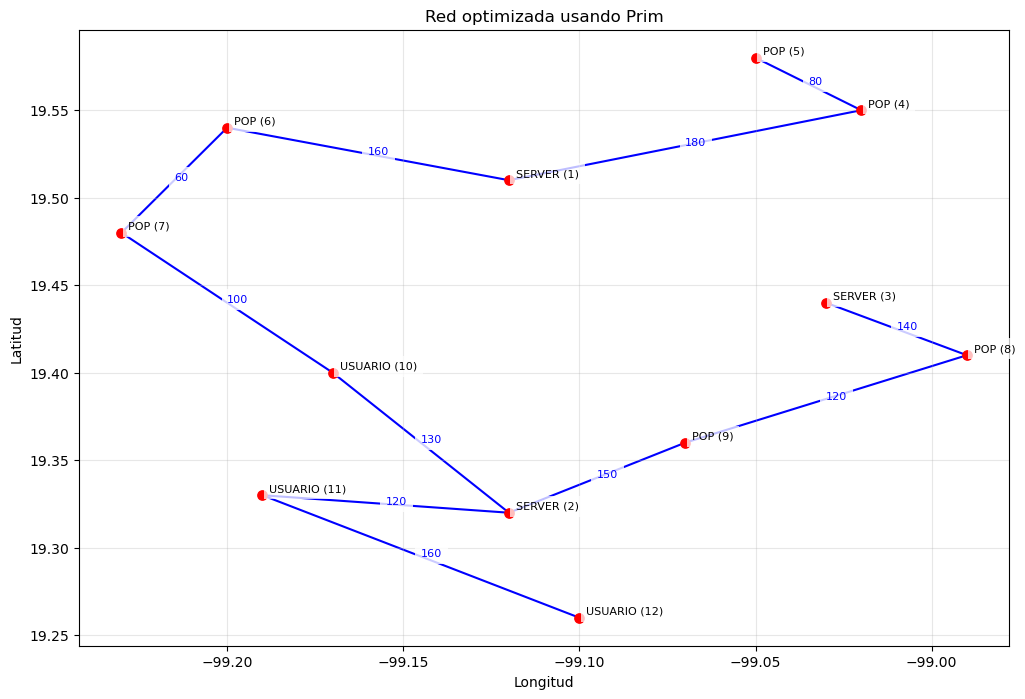

In [11]:
grafo.precalcular_pesos_combinados()
referencias = ExperimentoPrim.referencias_despues_prim_combinado(grafo) # Con este método llamamos al prim con 1 y generamos las referencias
direcciones_nodos = ExperimentoPrim.conexiones_con_pos(referencias)


# Guardar posiciones de nodos
x = []
y = []

# GRAFICAR NODOS Y ETIQUETAS
for tipo, latitud, longitud, id_nodo in nodos:

    x.append(longitud)
    y.append(latitud)

    # Texto del nodo
    texto = f"{tipo} ({id_nodo})"

    # Nodo
    plt.scatter(
        longitud,
        latitud,
        c='red',
        s=45,
        zorder=5
    )

    # Etiqueta del nodo
    plt.text(
        longitud + 0.002,
        latitud + 0.002,
        texto,
        fontsize=8,
        bbox=dict(
            facecolor='white',
            alpha=0.75,
            edgecolor='none'
        ),
        zorder=6
    )

# GRAFICAR ARISTAS Y LATENCIAS
for (origen_id, destino_id), (origen, destino) in zip(referencias, direcciones_nodos):

    # Coordenadas origen/destino
    lat1, lon1 = origen
    lat2, lon2 = destino

    # Dibujar línea
    plt.plot(
        [lon1, lon2],
        [lat1, lat2],
        'b-',
        linewidth=1.5,
        zorder=1
    )

    # Calcular punto medio
    mid_lon = (lon1 + lon2) / 2
    mid_lat = (lat1 + lat2) / 2

    # Obtener latencia desde el grafo
    costo_km = grafo.getOrigen()[origen_id][destino_id]["costo"]

    # Mostrar latencia en medio de la línea
    plt.text(
        mid_lon,
        mid_lat,
        str(costo_km),
        fontsize=8,
        color='blue',
        bbox=dict(
            facecolor='white',
            alpha=0.8,
            edgecolor='none'
        ),
        zorder=7
    )

# Títulos
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Red optimizada usando Prim")

# Cuadrícula
plt.grid(alpha=0.3)

# Mostrar resultado
plt.show()


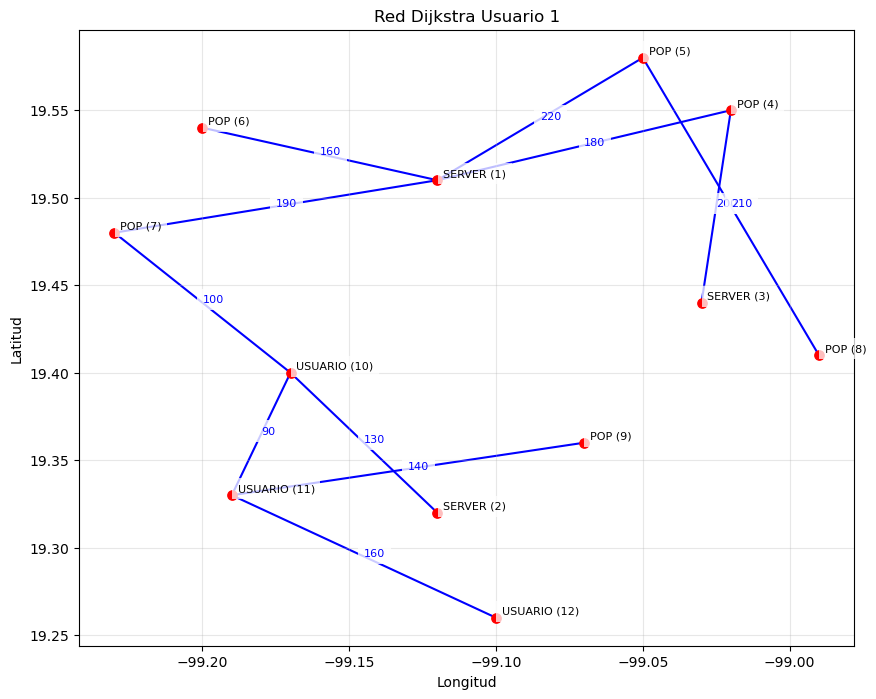

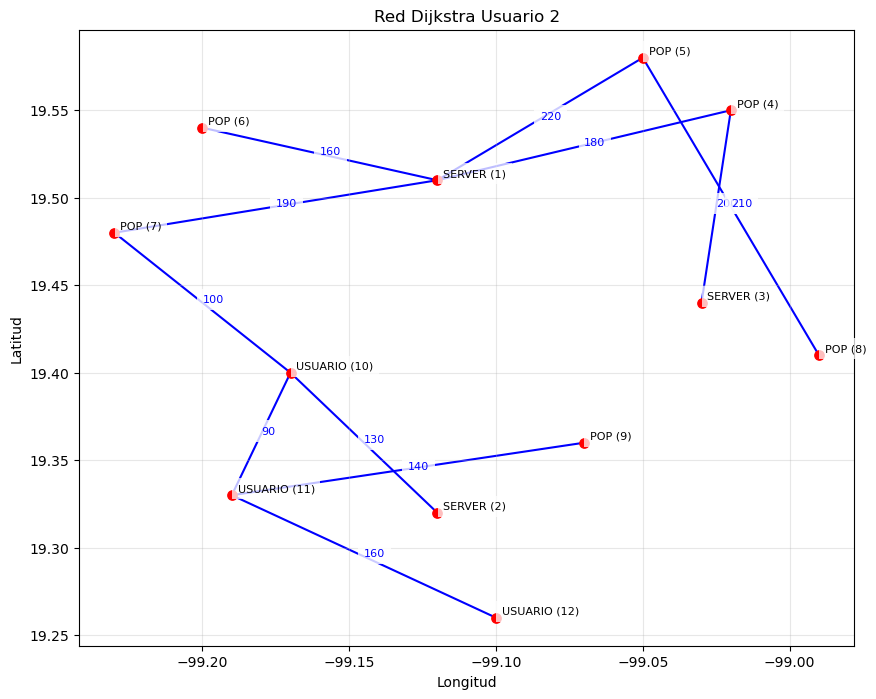

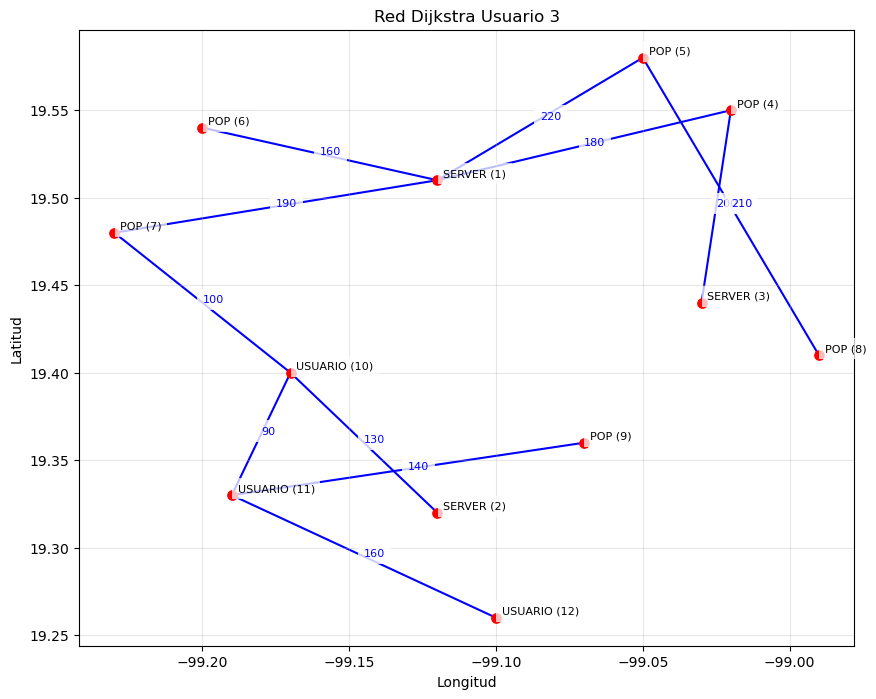

In [6]:
import matplotlib.pyplot as plt
import ExperimentoDijkstra
import ExperimentoPrim
import Grafo

grafo = Grafo.Grafo()
grafoC = ExperimentoPrim.insertaElementos(grafo)

referencias = []
direcciones = []

nodos = ExperimentoPrim.insertaNodos()

# =========================================
# OBTENER REFERENCIAS Y DIRECCIONES
# =========================================

for elem in nodos:

    if elem[0] == "USUARIO":

        ref = ExperimentoDijkstra.referencias_despues_Dijkstra(
            grafo
        )

        referencias.append(ref)

        direcciones.append(
            ExperimentoPrim.conexiones_con_pos(ref)
        )

# =========================================
# HACER UNA GRAFICA POR CADA USUARIO
# =========================================

for i, (referencia, direcciones_nodos) in enumerate(
    zip(referencias, direcciones)
):

    # NUEVA FIGURA
    plt.figure(figsize=(10, 8))

    # =====================================
    # GRAFICAR NODOS
    # =====================================

    for tipo, latitud, longitud, id_nodo in nodos:

        texto = f"{tipo} ({id_nodo})"

        plt.scatter(
            longitud,
            latitud,
            c='red',
            s=45,
            zorder=5
        )

        plt.text(
            longitud + 0.002,
            latitud + 0.002,
            texto,
            fontsize=8,
            bbox=dict(
                facecolor='white',
                alpha=0.75,
                edgecolor='none'
            ),
            zorder=6
        )

    # =====================================
    # GRAFICAR ARISTAS
    # =====================================

    for (origen_id, destino_id), (origen, destino) in zip(
        referencia,
        direcciones_nodos
    ):

        lat1, lon1 = origen
        lat2, lon2 = destino

        # Línea
        plt.plot(
            [lon1, lon2],
            [lat1, lat2],
            'b-',
            linewidth=1.5,
            zorder=1
        )

        # Punto medio
        mid_lon = (lon1 + lon2) / 2
        mid_lat = (lat1 + lat2) / 2

        # Costo
        costo_km = grafo.getOrigen()[origen_id][destino_id]["costo"]

        # Texto del costo
        plt.text(
            mid_lon,
            mid_lat,
            str(round(costo_km, 2)),
            fontsize=8,
            color='blue',
            bbox=dict(
                facecolor='white',
                alpha=0.8,
                edgecolor='none'
            ),
            zorder=7
        )

    # =====================================
    # CONFIGURACION
    # =====================================

    plt.xlabel("Longitud")
    plt.ylabel("Latitud")

    plt.title(f"Red Dijkstra Usuario {i+1}")

    plt.grid(alpha=0.3)

    # MOSTRAR ESTA FIGURA
    plt.show()